# Base de datos: Campañas de marketing directo (banca portuguesa)

## Integrantes:

    -   
    -   

# Introducción (aprendizaje no supervisado)

En este trabajo abordamos el conjunto de datos de campañas de marketing directo de una entidad bancaria portuguesa desde una **perspectiva no supervisada**. A diferencia de la clasificación tradicional —que utiliza la variable objetivo `subscribed`— aquí buscamos **descubrir estructuras latentes** en los datos sin recurrir a etiquetas: segmentar clientes, identificar patrones de contacto y reconocer perfiles con comportamientos similares que puedan guiar decisiones comerciales.

El objetivo principal es **construir segmentos accionables** que apoyen la planificación de campañas: qué perfiles conviene contactar, por qué canal y en qué momento, y cuáles muestran señales de baja respuesta. Para ello, combinamos atributos **demográficos** (`age`, `job`, `education`), de **historial de interacción** (`campaign`, `pdays`, `previous`, `poutcome`) y de **contexto macroeconómico** (`emp.var.rate`, `cons.price.idx`, `euribor3m`, `nr.employed`), evitando el uso de `duration` (porque induce fuga de información) y sin utilizar `subscribed` en el proceso de descubrimiento (solo podrá emplearse luego para **validación ex post** de los segmentos).

Dado que el conjunto mezcla **variables numéricas y categóricas**, el preprocesamiento es clave: tratamiento de valores `unknown`, codificación apropiada de categorías, y **escalado** de variables continuas. La exploración incluirá técnicas de **reducción de dimensionalidad** para visualizar la estructura global y algoritmos de **clustering** con evaluación interna y análisis de **interpretabilidad** (perfiles medios por cluster, importancia de rasgos).

El resultado esperado es un conjunto de **segmentos interpretables**, alineados con la realidad del negocio, que permitan diseñar estrategias diferenciadas de contacto y oferta, optimizando recursos y mejorando la eficacia de las campañas sin depender inicialmente de una etiqueta de éxito.


## Descripción general
Conjunto de datos de campañas de **marketing directo vía llamadas telefónicas** de una institución bancaria en Portugal. El objetivo típico es predecir si un cliente **suscribirá un depósito a plazo**.

- **Observación:** un contacto (cliente × campaña).
- **Variable ilustrativa:** `subscribed` (sí/no).

> **Importante (fuga de información):** la variable `duration` solo se conoce **durante/después** de la llamada y está fuertemente correlacionada con el resultado. Para un modelo **realista en producción**, **no** debe usarse como predictor; puede utilizarse solo para **benchmarks**.

---

## Diccionario de datos

| # | Variable | Tipo | Descripción | Valores posibles |
|---:|---|---|---|---|
| 1 | `age` | numérico | Edad del cliente. | — |
| 2 | `job` | categórica | Tipo de empleo. | `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown` |
| 3 | `marital` | categórica | Estado civil (*divorced* incluye divorciado/viudo). | `divorced`, `married`, `single`, `unknown` |
| 4 | `education` | categórica | Nivel educativo. | `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown` |
| 5 | `default` | categórica | ¿Crédito en mora/incumplimiento? | `no`, `yes`, `unknown` |
| 6 | `housing` | categórica | ¿Crédito hipotecario? | `no`, `yes`, `unknown` |
| 7 | `loan` | categórica | ¿Préstamo personal? | `no`, `yes`, `unknown` |
| 8 | `contact` | categórica | Canal del último contacto de la campaña actual. | `cellular`, `telephone` |
| 9 | `month` | categórica | Mes del último contacto. | `jan`, `feb`, `mar`, …, `nov`, `dec` |
|10 | `day_of_week` | categórica | Día de la semana del último contacto. | `mon`, `tue`, `wed`, `thu`, `fri` |
|11 | `duration` | numérico | Duración del último contacto (segundos). **Ver nota de fuga.** | — |
|12 | `campaign` | numérico | # de contactos en **esta** campaña (incluye el último). | — |
|13 | `pdays` | numérico | Días desde el último contacto en campañas previas (`999` = nunca contactado). | — |
|14 | `previous` | numérico | # de contactos **previos** a esta campaña. | — |
|15 | `poutcome` | categórica | Resultado de la campaña previa. | `failure`, `nonexistent`, `success` |
|16 | `emp.var.rate` | numérico | Tasa de variación del empleo (trimestral). | — |
|17 | `cons.price.idx` | numérico | Índice de precios al consumidor (mensual). | — |
|18 | `cons.conf.idx` | numérico | Índice de confianza del consumidor (mensual). | — |
|19 | `euribor3m` | numérico | Tasa Euribor a 3 meses (diaria). | — |
|20 | `nr.employed` | numérico | Número de empleados (trimestral). | — |
|21 | `subscribed` | binaria (objetivo) | ¿Suscribió depósito a plazo? | `yes`, `no` |

---

## Notas de modelado
- **Predictores recomendados:** variables demográficas (`age`, `job`, `education`, etc.), historial de campañas (`campaign`, `pdays`, `previous`, `poutcome`) y contexto macro (`emp.var.rate`, `euribor3m`, etc.).
- **Evitar en producción:** `duration` (conduce a **target leakage**).
- **Codificación:** tratar `unknown` como categoría explícita; considerar *one-hot encoding* para variables categóricas.
- **Escalas:** normalizar/estandarizar predictores continuos si se usan modelos sensibles a escala.


In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import prince
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score)

In [140]:
data = pd.read_csv("bank_marketing_dataset.csv")
data = data.drop(columns=['subscribed'])  # Eliminar columna irrelevante
pd.set_option('display.max_columns', None)
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0


In [141]:
COLOR_PRIN = '#2a78d6'   # azul    - slot categórico 1
COLOR_SEC  = '#eb6834'   # naranja - slot categórico 2
COLOR_GRID = '#e1e0d9'
COLOR_AXIS = '#898781'
COLOR_TEXT = '#0b0b0b'
SURFACE    = '#fcfcfb'

plt.rcParams.update({
    'axes.edgecolor': COLOR_AXIS,
    'axes.labelcolor': COLOR_TEXT,
    'xtick.color': COLOR_AXIS,
    'ytick.color': COLOR_AXIS,
    'text.color': COLOR_TEXT,
    'axes.grid': True,
    'grid.color': COLOR_GRID,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
})


def clean_ax(ax):
    """Quita bordes superior/derecho y manda la grilla detrás de los datos."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)


# ✅ Criterios de evaluación – Aprendizaje no supervisado

1) **Análisis exploratorio completo y preparación de datos**  
Realiza un **EDA** que caracterice la distribución de variables, relaciones relevantes y posibles sesgos: incluye tendencias, dispersión, outliers, correlaciones/associaciones y calidad de datos (faltantes y categorías `unknown`). A partir de este diagnóstico, deja el dataset listo para agrupar: tratamiento de faltantes, codificación de categóricas y escalado de continuas, justificando cada decisión y evitando fugas de información (no usar `subscribed` ni `duration` como insumo del clustering).

2) **Proyección y visualización de la estructura**  
Emplea una técnica de reducción de dimensionalidad (p. ej., PCA o UMAP) para explorar la forma global de los datos y sugerir separaciones naturales. Presenta visualizaciones claras que faciliten interpretar la estructura latente.

3) **Modelado de clusters**  
Selecciona y ejecuta un algoritmo acorde al tipo de variables (p. ej., k-means/k-medoids, k-prototypes, DBSCAN o mezcla gaussiana). Define y justifica los hiperparámetros (incluido el número de clusters cuando aplique) y reporta la estabilidad/consistencia de la solución.

4) **Descripción de los clusters**  
Perfila cada segmento en términos de sus rasgos distintivos (demografía, historial de campañas y contexto). Entrega un resumen comparativo (tablas/gráficos) que muestre claramente cómo difieren los clusters. **Las acciones comerciales derivadas** deberán ser propuestas aparte por los estudiantes; aquí se califica la **calidad y claridad de la descripción**.


### Punto 1

In [142]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [143]:
data.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64

In [144]:
def contar_valor(df, valor):
    conteo = (df == valor).sum()
    return pd.DataFrame({
        "Conteo": conteo,
        "%": (conteo / len(df) * 100).round(2),
    }).sort_values("Conteo", ascending=False)

contar_valor(data, 'unknown')

,Conteo,%
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19
age,0,0.00
contact,0,0.00
month,0,0.00
day_of_week,0,0.00


In [145]:
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [146]:
cat_cols = data.select_dtypes(include=['str']).columns
for col in (cat_cols):
    print(f"\nTop 5 valores más frecuentes en '{col}':\n")
    print(data[col].value_counts().head())



Top 5 valores más frecuentes en 'job':

job
admin.         10422
blue-collar     9254
technician      6743
services        3969
management      2924
Name: count, dtype: int64

Top 5 valores más frecuentes en 'marital':

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

Top 5 valores más frecuentes en 'education':

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
Name: count, dtype: int64

Top 5 valores más frecuentes en 'default':

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Top 5 valores más frecuentes en 'housing':

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

Top 5 valores más frecuentes en 'loan':

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

Top 5 valores más frecuentes en 'contact':

contact
cellular

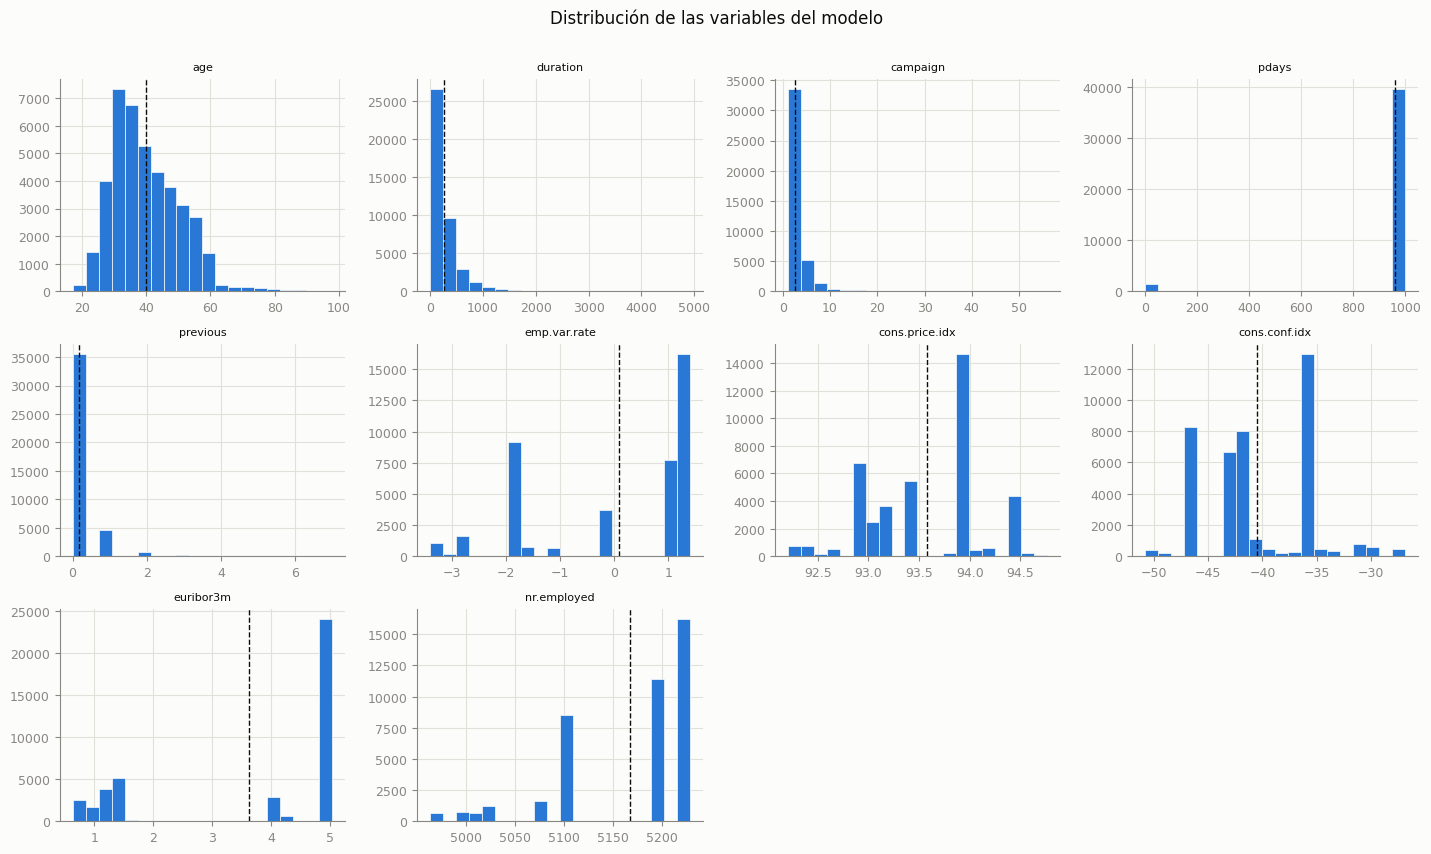

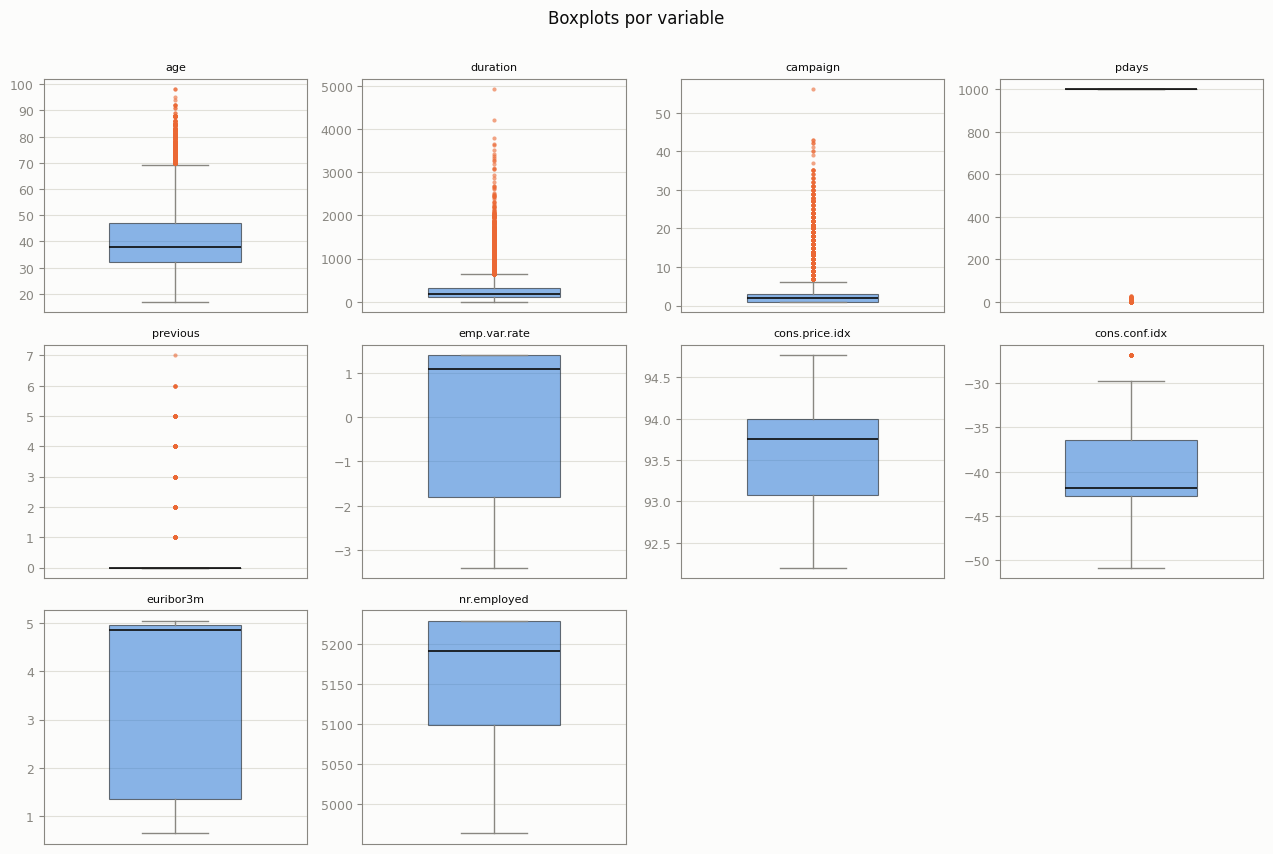

In [147]:
# ---------------------------------------------------------------
# Histogramas
# ---------------------------------------------------------------
n_cols = 4
n_vars = len(num_cols)
n_rows = -(-n_vars // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.6, n_rows * 2.8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    datos = data[col].dropna()
    ax = axes[i]
    ax.hist(datos, bins=20, color=COLOR_PRIN, edgecolor=SURFACE, linewidth=0.5)
    ax.axvline(datos.mean(), color=COLOR_TEXT, linewidth=1, linestyle='--')
    ax.set_title(col, fontsize=8)
    clean_ax(ax)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Distribución de las variables del modelo', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Boxplots
# ---------------------------------------------------------------
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 2.8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    datos = data[col].dropna()
    ax = axes[i]
    ax.boxplot(
        datos, vert=True, patch_artist=True, widths=0.5,
        boxprops=dict(facecolor=COLOR_PRIN, alpha=0.55, edgecolor=COLOR_TEXT, linewidth=0.8),
        medianprops=dict(color=COLOR_TEXT, linewidth=1.2),
        whiskerprops=dict(color=COLOR_AXIS),
        capprops=dict(color=COLOR_AXIS),
        flierprops=dict(markerfacecolor=COLOR_SEC, markeredgecolor='none',
                        markersize=3, alpha=0.6),
    )
    ax.set_title(col, fontsize=8)
    ax.set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Boxplots por variable', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

In [148]:
UMBRAL_Z = 3.0

resumen = []
for col in num_cols:
    datos = data[col]
    z = (datos - datos.mean()) / datos.std()
    mascara = z.abs() > UMBRAL_Z
    resumen.append({
        "Variable": col,
        "Media": datos.mean(),
        "Desv. est.": datos.std(),
        "Límite inferior": datos.mean() - UMBRAL_Z * datos.std(),
        "Límite superior": datos.mean() + UMBRAL_Z * datos.std(),
        'Min': datos.min(),
        'Max': datos.max(),
        "Atípicos": int(mascara.sum()),
        "% del total": round(100 * mascara.mean(), 2)
    })

resumen = pd.DataFrame(resumen).sort_values("Atípicos", ascending=False)
display(resumen.round(3))

,Variable,Media,Desv. est.,Límite inferior,Límite superior,Min,Max,Atípicos,% del total
3,pdays,962.475,186.911,401.743,1523.208,0.000,999.000,1515,3.68
4,previous,0.173,0.495,-1.312,1.658,0.000,7.000,1064,2.58
2,campaign,2.568,2.770,-5.742,10.878,1.000,56.000,869,2.11
1,duration,258.285,259.279,-519.553,1036.123,0.000,4918.000,861,2.09
0,age,40.024,10.421,8.760,71.288,17.000,98.000,369,0.90
5,emp.var.rate,0.082,1.571,-4.631,4.795,-3.400,1.400,0,0.00
6,cons.price.idx,93.576,0.579,91.839,95.312,92.201,94.767,0,0.00
7,cons.conf.idx,-40.503,4.628,-54.387,-26.618,-50.800,-26.900,0,0.00
8,euribor3m,3.621,1.734,-1.582,8.825,0.634,5.045,0,0.00
9,nr.employed,5167.036,72.252,4950.281,5383.790,4963.600,5228.100,0,0.00


In [149]:
data['pdays'].value_counts().sort_index()

pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64

In [150]:
df = data.copy()

df['pweeks'] = pd.cut(
    df['pdays'],
    bins=[0, 7, 14, 21, 28, 1000],
    labels=['una_semana', 'dos_semanas', 'tres_semanas', 'cuatro_semanas', 'nunca'],
    right=False   # intervalo [a, b) no [a, b]
)
df = df.drop(columns=['pdays', 'duration'])

num_cols = df.select_dtypes(include=['float64', 'int64']).columns.to_list()
cat_cols = df.select_dtypes(include=['str', 'category']).columns.to_list()
print("Numericas:\n", num_cols)
print("\nCategoricas:\n", cat_cols)

Numericas:
 ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categoricas:
 ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'pweeks']


### Punto 2

In [151]:
scaler = StandardScaler()

df_esc = df.copy()
df_esc[num_cols] = scaler.fit_transform(df_esc[num_cols])

Eigenvalue promedio: 1.5763 -> 5 factores


,Factor,Eigenvalue,Inercia (%),Acumulada (%)
0,F1,5.0695,16.93,16.93
1,F2,2.2439,7.49,24.42
2,F3,2.1276,7.10,31.52
3,F4,2.0004,6.68,38.20
4,F5,1.9361,6.46,44.67
5,F6,1.5197,5.07,49.74
6,F7,1.4715,4.91,54.65
7,F8,1.3944,4.66,59.31
8,F9,1.3459,4.49,63.80
9,F10,1.2681,4.23,68.04


Inercia >= 85% -> 15 factores


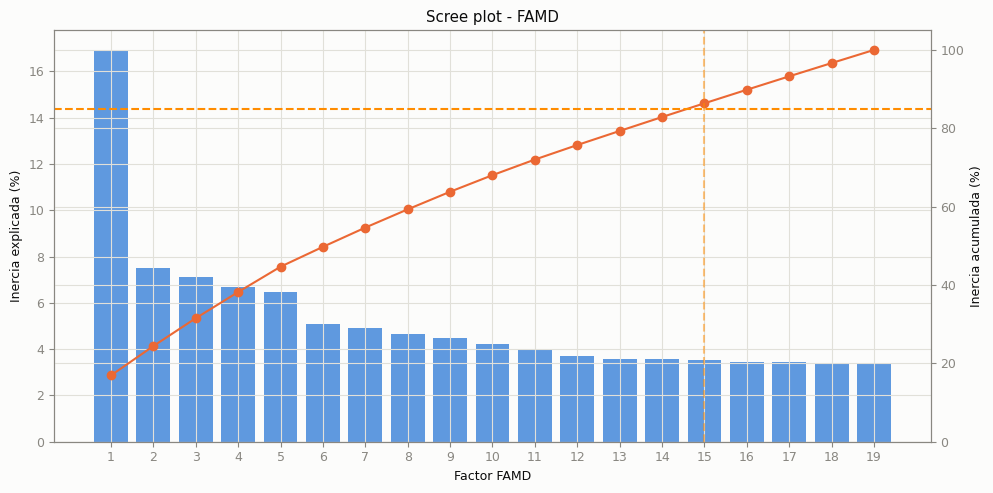


Forma final: (41188, 15)
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       41188 non-null  float64
 1   1       41188 non-null  float64
 2   2       41188 non-null  float64
 3   3       41188 non-null  float64
 4   4       41188 non-null  float64
 5   5       41188 non-null  float64
 6   6       41188 non-null  float64
 7   7       41188 non-null  float64
 8   8       41188 non-null  float64
 9   9       41188 non-null  float64
 10  10      41188 non-null  float64
 11  11      41188 non-null  float64
 12  12      41188 non-null  float64
 13  13      41188 non-null  float64
 14  14      41188 non-null  float64
dtypes: float64(15)
memory usage: 4.7 MB


In [152]:
modelo = prince.FAMD(n_components=min(50, len(df_esc.columns)), random_state=42)
_ = modelo.fit(df_esc)

# Diagnóstico
# Kaiser generalizado: el eigenvalue promedio es la inercia total / nº de dimensiones
eig = np.asarray(modelo.eigenvalues_, dtype=float)
eig_promedio = eig.mean()
n_kaiser_famd = int((eig > eig_promedio).sum())
print(f"Eigenvalue promedio: {eig_promedio:.4f} -> {n_kaiser_famd} factores")

eig = np.asarray(modelo.eigenvalues_, dtype=float)
inercia_pct = eig / eig.sum() * 100
acum = inercia_pct.cumsum()

diag_famd = pd.DataFrame({
    "Factor": [f"F{i}" for i in range(1, len(eig) + 1)],
    "Eigenvalue": eig.round(4),
    "Inercia (%)": inercia_pct.round(2),
    "Acumulada (%)": acum.round(2),
})
display(diag_famd.head(30))

UMBRAL = 85
n_final = int(np.searchsorted(acum, UMBRAL) + 1)
print(f"Inercia >= {UMBRAL}% -> {n_final} factores")

# Scree plot (igual que antes, solo que un gráfico)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(1, len(inercia_pct) + 1), inercia_pct, color=COLOR_PRIN, alpha=0.75)
ax1.set_xlabel("Factor FAMD")
ax1.set_ylabel("Inercia explicada (%)")
ax1.set_xticks(range(1, min(31, len(inercia_pct) + 1)))

ax2 = ax1.twinx()
ax2.plot(range(1, len(acum) + 1), acum, marker="o", color=COLOR_SEC)
ax2.axhline(UMBRAL, color="darkorange", linestyle="--")
ax2.axvline(n_final, color="darkorange", linestyle="--", alpha=0.5)
ax2.set_ylabel("Inercia acumulada (%)")
ax2.set_ylim(0, 105)
plt.title("Scree plot - FAMD")
plt.tight_layout()
plt.show()

# DataFrame final
modelo = prince.FAMD(n_components=n_final, random_state=42)
df_modelo = modelo.fit_transform(df_esc)
print(f"\nForma final: {df_modelo.shape}")
df_modelo.info()

In [153]:
# ---------------------------------------------------------------
# Ajuste sobre TODAS las dimensiones reales
# ---------------------------------------------------------------
n_num = len(num_cols)
K = len(cat_cols)
J = int(sum(df_esc[c].nunique() for c in cat_cols))
n_max = n_num + (J - K)

print(f"Numéricas: {n_num} | Categóricas: {K} | Categorías: {J}")
print(f"Dimensiones del FAMD: {n_max}")

modelo_full = prince.FAMD(n_components=n_max, random_state=42).fit(df_esc)

eig = np.asarray(modelo_full.eigenvalues_, dtype=float)
inercia_pct = eig / eig.sum() * 100
acum = inercia_pct.cumsum()
eig_promedio = eig.mean()

print(f"Factores calculados: {len(eig)}")
print(f"Inercia total: {eig.sum():.2f} | Eigenvalue promedio: {eig_promedio:.4f}")

# ---------------------------------------------------------------
# Criterios de decisión
# ---------------------------------------------------------------
n_kaiser = int((eig > eig_promedio).sum())

# Diferencias sucesivas: dónde está el escalón más grande
saltos = -np.diff(eig)
n_codo = int(np.argmax(saltos) + 1)

print(f"\nKaiser (eig > promedio) -> {n_kaiser} factores")
print(f"Mayor caída entre factores consecutivos: F{n_codo} -> F{n_codo+1}")

diag_famd = pd.DataFrame({
    "Factor": [f"F{i}" for i in range(1, len(eig) + 1)],
    "Eigenvalue": eig.round(4),
    "Inercia (%)": inercia_pct.round(2),
    "Acumulada (%)": acum.round(2),
    "Caída al siguiente": np.append(saltos, np.nan).round(4),
    "Supera promedio": eig > eig_promedio,
})
display(diag_famd)

Numéricas: 8 | Categóricas: 11 | Categorías: 58
Dimensiones del FAMD: 55
Factores calculados: 55
Inercia total: 55.00 | Eigenvalue promedio: 1.0000

Kaiser (eig > promedio) -> 23 factores
Mayor caída entre factores consecutivos: F1 -> F2


,Factor,Eigenvalue,Inercia (%),Acumulada (%),Caída al siguiente,Supera promedio
0,F1,5.0695,9.22,9.22,2.8245,True
1,F2,2.2450,4.08,13.30,0.1162,True
2,F3,2.1288,3.87,17.17,0.1239,True
3,F4,2.0049,3.65,20.81,0.0657,True
4,F5,1.9392,3.53,24.34,0.4059,True
5,F6,1.5333,2.79,27.13,0.0417,True
6,F7,1.4916,2.71,29.84,0.0849,True
7,F8,1.4067,2.56,32.40,0.0485,True
8,F9,1.3582,2.47,34.87,0.0699,True
9,F10,1.2883,2.34,37.21,0.0775,True


In [154]:
# ---------------------------------------------------------------
# 3. Análisis paralelo por permutación
# ---------------------------------------------------------------
N_PERM = 30                       # sube a 100 si el dataset es pequeño
rng = np.random.default_rng(42)
eig_nulo = []

for _ in range(N_PERM):
    df_perm = df_esc.apply(lambda col: rng.permutation(col.values))
    eig_nulo.append(np.asarray(
        prince.FAMD(n_components=n_max, random_state=42)
        .fit(df_perm).eigenvalues_, dtype=float))

eig_nulo = np.vstack(eig_nulo)
corte_p95 = np.percentile(eig_nulo, 95, axis=0)
n_permutacion = int(np.argmax(eig <= corte_p95)) or len(eig)

print(f"Factores que superan el ruido: {n_permutacion}")
display(pd.DataFrame({
    "Factor": [f"F{i}" for i in range(1, len(eig) + 1)],
    "Eigenvalue real": eig.round(4),
    "P95 bajo H0": corte_p95.round(4),
    "Supera el ruido": eig > corte_p95,
}))

KeyboardInterrupt: 

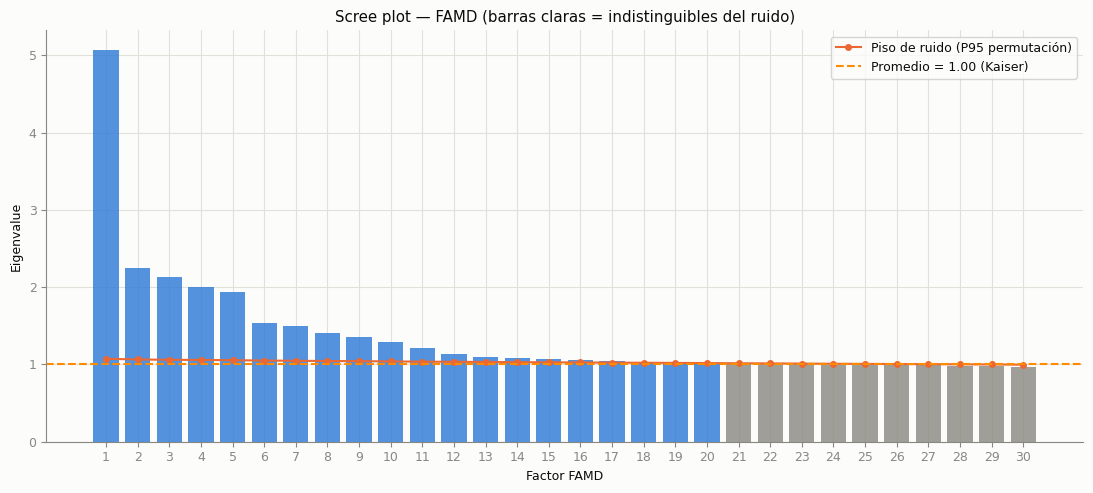

In [ ]:
# ---------------------------------------------------------------
# 4. Scree plot corregido
# ---------------------------------------------------------------
n_mostrar = min(30, len(eig))
factores = np.arange(1, n_mostrar + 1)

fig, ax = plt.subplots(figsize=(11, 5))
colores_barra = [COLOR_PRIN if e > corte_p95[i] else COLOR_AXIS
                 for i, e in enumerate(eig[:n_mostrar])]
ax.bar(factores, eig[:n_mostrar], color=colores_barra, alpha=0.8)
ax.plot(factores, corte_p95[:n_mostrar], marker="o", markersize=4,
        color=COLOR_SEC, linewidth=1.5, label="Piso de ruido (P95 permutación)")
ax.axhline(eig_promedio, color="darkorange", linestyle="--",
           label=f"Promedio = {eig_promedio:.2f} (Kaiser)")
ax.set_xlabel("Factor FAMD")
ax.set_ylabel("Eigenvalue")
ax.set_xticks(factores)
ax.set_title("Scree plot — FAMD (barras claras = indistinguibles del ruido)")
ax.legend()
clean_ax(ax)
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------
# 5. Qué significa cada factor
# ---------------------------------------------------------------
N_FACTORES = n_permutacion        # decisión explícita: cámbialo si eliges otro criterio

modelo = prince.FAMD(n_components=N_FACTORES, random_state=42).fit(df_esc)
df_modelo = modelo.row_coordinates(df_esc)
df_modelo.columns = [f"F{i}" for i in range(1, N_FACTORES + 1)]
df_modelo.index = df_esc.index

n_ver = min(4, N_FACTORES)

# Numéricas: correlación con cada factor (equivalente al círculo de correlaciones)
corr_num = pd.DataFrame(
    {f: [df_esc[c].corr(df_modelo[f]) for c in num_cols]
     for f in df_modelo.columns[:n_ver]},
    index=num_cols,
)
print("Correlación de las variables numéricas con los factores:")
display(corr_num.round(3))

# Categóricas: centroide de cada categoría en el espacio factorial
bloques = []
for c in cat_cols:
    g = df_modelo.iloc[:, :n_ver].groupby(df_esc[c].values).mean()
    g.index = [f"{c} = {i}" for i in g.index]
    bloques.append(g)
coord_cat = pd.concat(bloques)

print("\nCategorías que más definen F1 y F2:")
display(coord_cat.reindex(
    coord_cat.iloc[:, :2].abs().sum(axis=1).sort_values(ascending=False).index
).round(3).head(20))

print(f"\nForma final: {df_modelo.shape}")
print(f"Inercia retenida: {acum[N_FACTORES-1]:.2f} % (escala FAMD, no comparable con ACP)")

Correlación de las variables numéricas con los factores:


,F1,F2,F3,F4
age,-0.009,0.450,0.269,-0.324
campaign,-0.188,0.020,-0.026,0.026
previous,0.658,0.331,-0.006,0.070
emp.var.rate,-0.920,0.147,-0.163,0.037
cons.price.idx,-0.715,0.301,0.060,0.124
cons.conf.idx,-0.173,0.505,-0.354,-0.021
euribor3m,-0.924,0.137,-0.187,0.021
nr.employed,-0.895,-0.040,-0.158,-0.003



Categorías que más definen F1 y F2:


,F1,F2,F3,F4
pweeks = una_semana,5.747,5.361,-1.698,0.727
poutcome = success,5.649,5.158,-1.573,0.781
pweeks = tres_semanas,5.500,3.660,-1.466,0.561
pweeks = dos_semanas,5.428,3.714,-0.635,1.049
pweeks = cuatro_semanas,5.034,3.263,-0.981,-0.877
month = sep,4.473,2.954,-0.853,0.162
month = dec,4.553,2.605,-0.531,-0.032
month = oct,3.992,2.128,-0.444,-0.076
month = apr,2.744,-1.566,1.096,-0.276
poutcome = failure,3.265,-0.614,0.730,-0.034



Forma final: (41188, 20)
Inercia retenida: 56.80 % (escala FAMD, no comparable con ACP)


### Punto 3

Inercia total (K=1): 549494.42


,K,Inercia (WCSS),Inercia explicada (%),Silhouette,Calinski-Harabasz,Davies-Bouldin,Reducción vs K anterior (%)
0,2,372579.708,32.196,0.398,19556.646,1.208,NaN
1,3,295440.870,46.234,0.410,17707.766,0.957,20.704
2,4,220769.152,59.823,0.437,20440.997,0.801,25.275


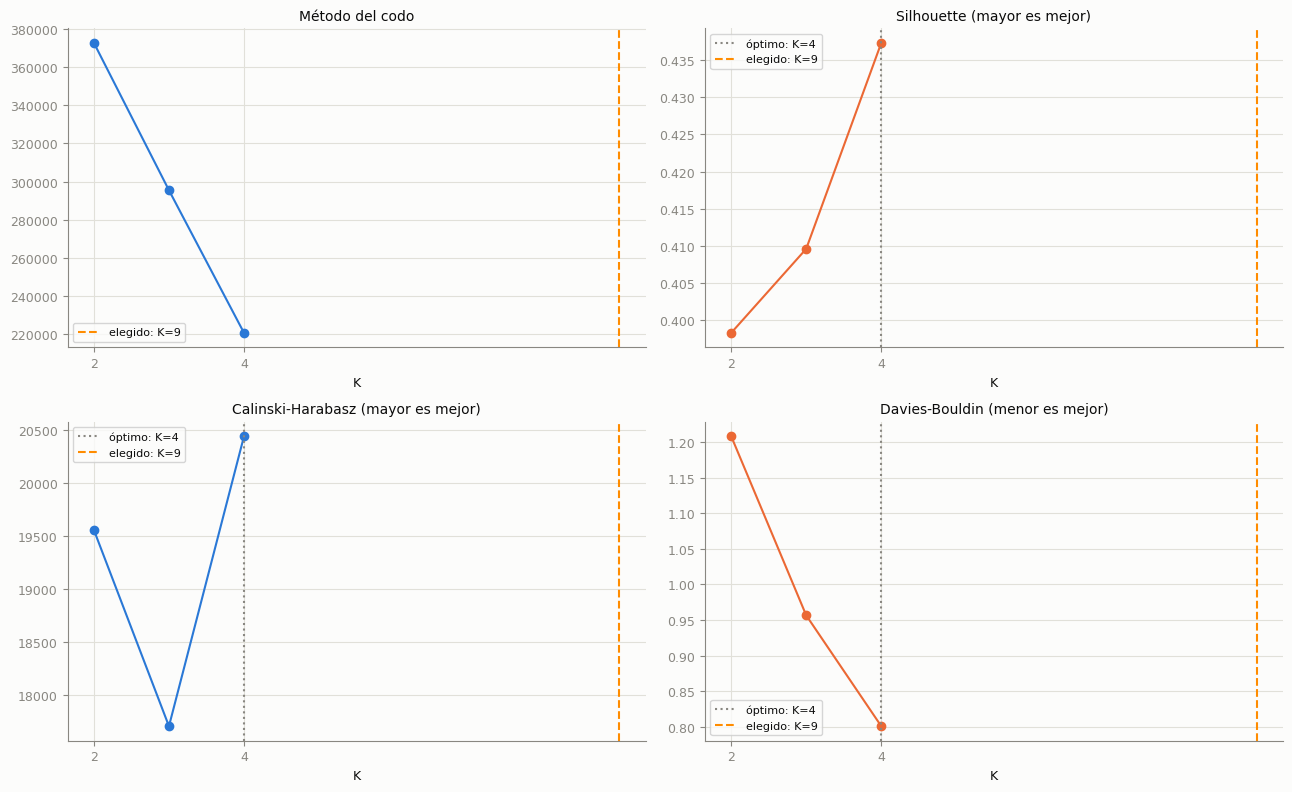

N=5: silhouette = 0.309
Inercia total (K=1): 1062096.34


,K,Inercia (WCSS),Inercia explicada (%),Silhouette,Calinski-Harabasz,Davies-Bouldin,Reducción vs K anterior (%)
0,2,884157.318,16.754,0.220,8288.792,2.039,NaN
1,3,799129.162,24.759,0.217,6776.316,1.737,9.617
2,4,737742.070,30.539,0.147,6035.626,1.976,7.682
3,5,700088.738,34.084,0.156,5323.811,2.072,5.104
4,6,629147.000,40.764,0.166,5667.907,1.683,10.133
5,7,592850.585,44.181,0.175,5432.515,1.770,5.769
6,8,568510.979,46.473,0.182,5107.539,1.752,4.106
7,9,549895.021,48.226,0.174,4794.541,1.711,3.275
8,10,528319.422,50.257,0.173,4622.603,1.768,3.924
9,11,512567.578,51.740,0.168,4414.635,1.678,2.981


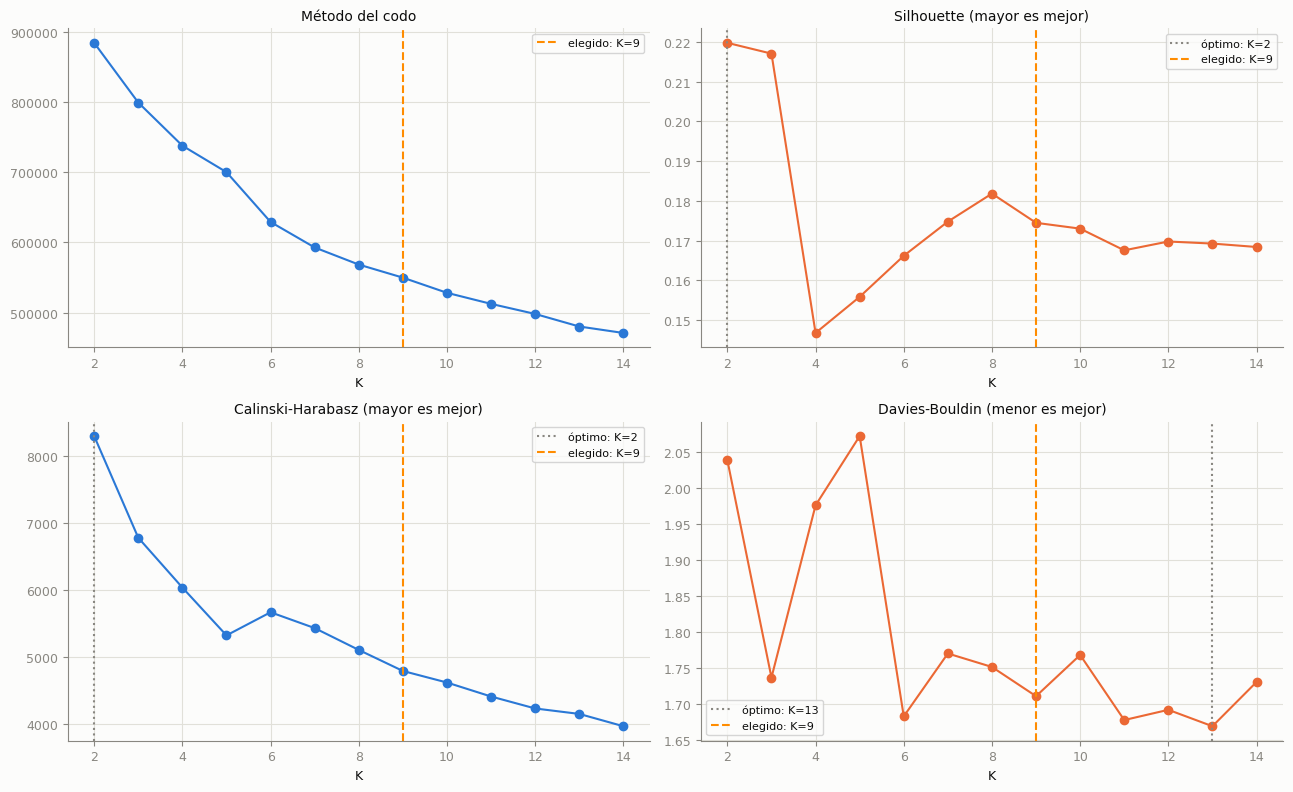

N=15: silhouette = 0.157
Inercia total (K=1): 1275623.37


,K,Inercia (WCSS),Inercia explicada (%),Silhouette,Calinski-Harabasz,Davies-Bouldin,Reducción vs K anterior (%)
0,2,1097428.147,13.969,0.193,6687.589,2.257,NaN
1,3,1011479.092,20.707,0.189,5377.660,1.939,7.832
2,4,948848.215,25.617,0.118,4727.807,2.214,6.192
3,5,874642.752,31.434,0.131,4720.097,1.914,7.821
4,6,846838.363,33.614,0.123,4170.389,1.927,3.179
5,7,807633.524,36.687,0.131,3977.111,2.007,4.630
6,8,775524.367,39.204,0.145,3793.581,1.986,3.976
7,9,748341.240,41.335,0.154,3626.847,1.909,3.505
8,10,742969.795,41.756,0.146,3280.171,1.841,0.718
9,11,710997.527,44.263,0.143,3269.997,1.931,4.303


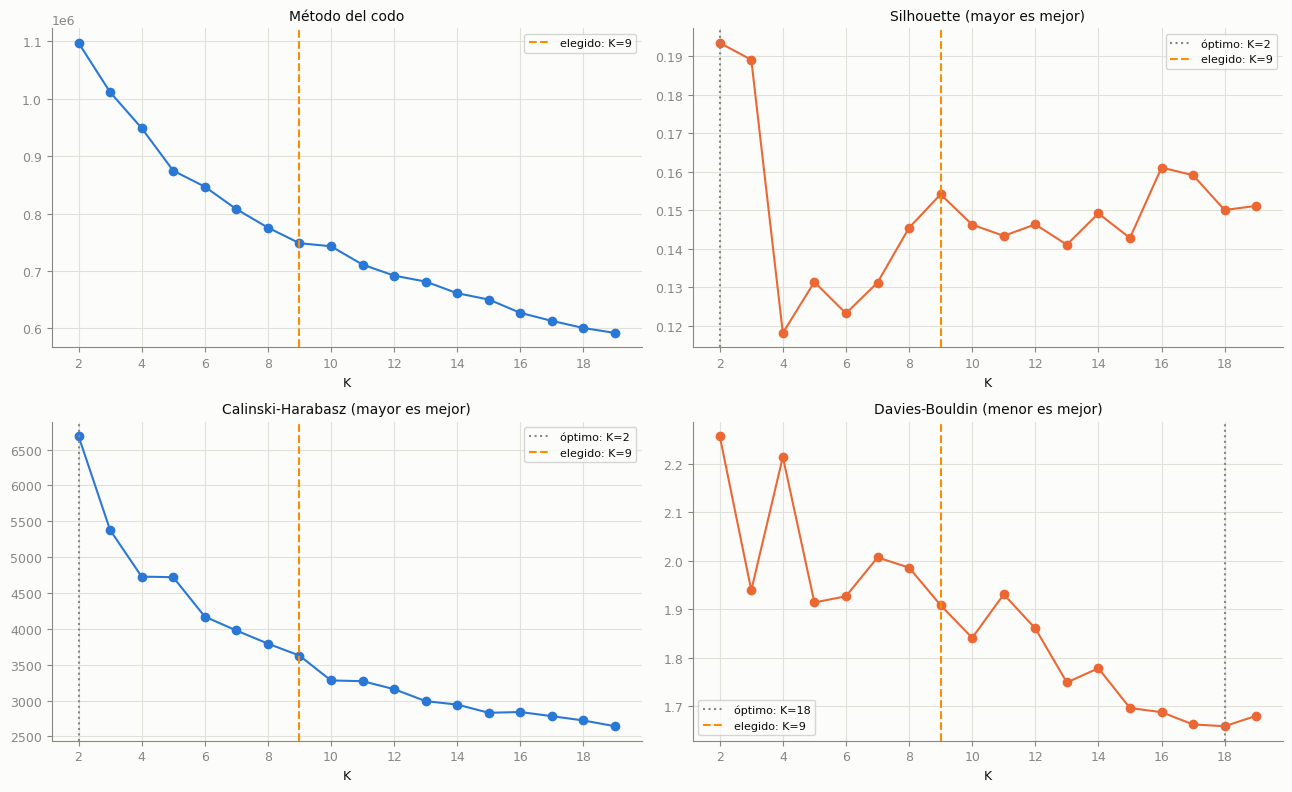

N=20: silhouette = 0.102
Inercia total (K=1): 1402156.93


,K,Inercia (WCSS),Inercia explicada (%),Silhouette,Calinski-Harabasz,Davies-Bouldin,Reducción vs K anterior (%)
0,2,1223905.367,12.713,0.183,5998.396,2.362,NaN
1,3,1137882.766,18.848,0.177,4782.625,2.036,7.029
2,4,1061773.532,24.276,0.188,4400.924,1.750,6.689
3,5,1000853.989,28.620,0.116,4128.191,2.019,5.738
4,6,964884.074,31.186,0.120,3732.629,2.019,3.594
5,7,935789.113,33.261,0.130,3420.556,2.139,3.015
6,8,923036.123,34.170,0.118,3053.618,1.875,1.363
7,9,884115.318,36.946,0.122,3016.075,2.014,4.217
8,10,860607.059,38.623,0.124,2879.099,2.138,2.659
9,11,839259.374,40.145,0.134,2761.773,2.016,2.481


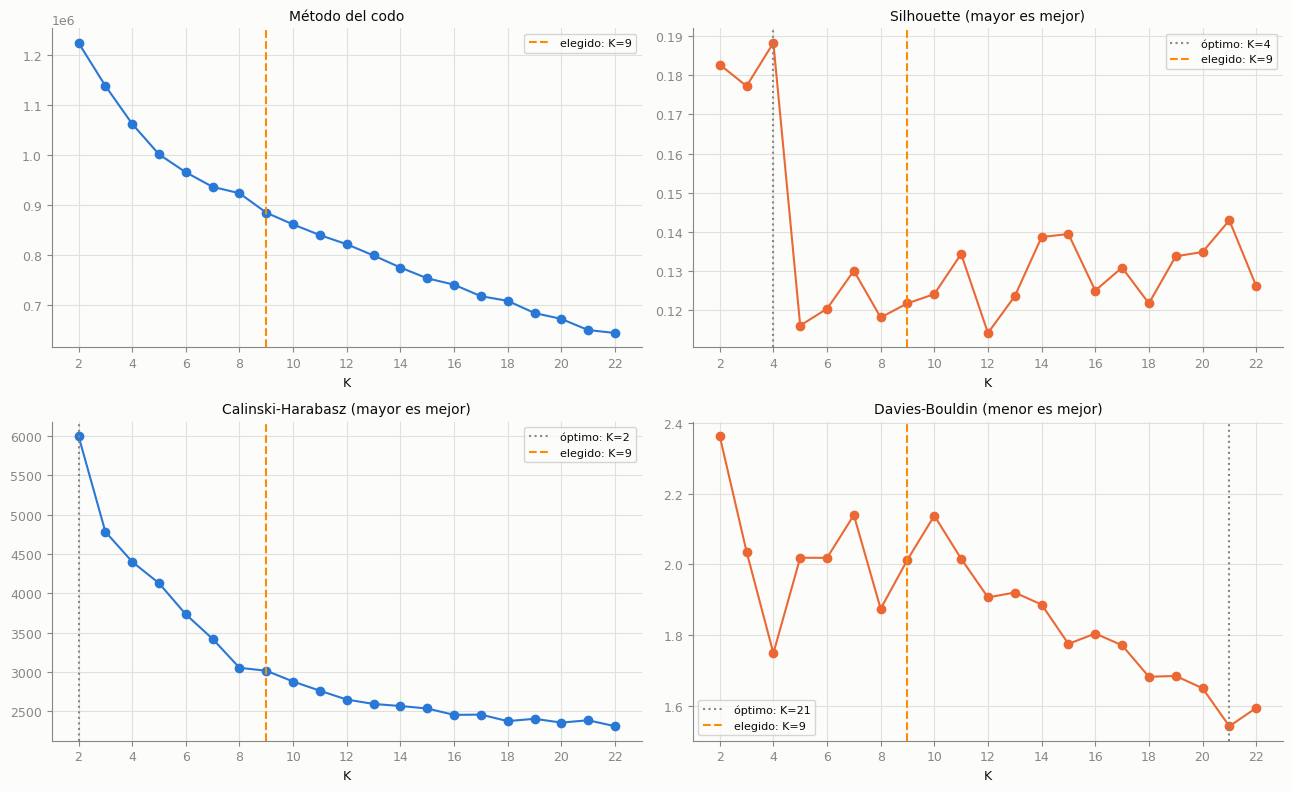

N=23: silhouette = 0.105


In [160]:
# Rápido: ajusta dos modelos con distintos N_FACTORES
for n_f in [5, 15, 20, 23]:
    modelo_temp = prince.FAMD(n_components=n_f, random_state=42).fit(df_esc)
    coords_temp = modelo_temp.row_coordinates(df_esc)

    inercia_total = KMeans(n_clusters=1, random_state=42, n_init=10).fit(coords_temp).inertia_
    print("Inercia total (K=1):", round(inercia_total, 2))

    rango_k = range(2, n_f)
    diagnostico_k = []

    for k in rango_k:
        modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
        etiquetas = modelo.fit_predict(coords_temp)
        diagnostico_k.append({
            "K": k,
            "Inercia (WCSS)": modelo.inertia_,
            "Inercia explicada (%)": 100 * (1 - modelo.inertia_ / inercia_total),
            "Silhouette": silhouette_score(coords_temp, etiquetas),
            "Calinski-Harabasz": calinski_harabasz_score(coords_temp, etiquetas),
            "Davies-Bouldin": davies_bouldin_score(coords_temp, etiquetas),
        })

    diagnostico_k = pd.DataFrame(diagnostico_k)
    diagnostico_k["Reducción vs K anterior (%)"] = (
        -diagnostico_k["Inercia (WCSS)"].pct_change() * 100
    )
    display(diagnostico_k.round(3))

    k_elegido = 9   # <-- fijar después de leer la tabla y los cuatro paneles

    paneles = [
        ("Inercia (WCSS)", "Método del codo", COLOR_PRIN, None),
        ("Silhouette", "Silhouette (mayor es mejor)", COLOR_SEC, "max"),
        ("Calinski-Harabasz", "Calinski-Harabasz (mayor es mejor)", COLOR_PRIN, "max"),
        ("Davies-Bouldin", "Davies-Bouldin (menor es mejor)", COLOR_SEC, "min"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ax, (col, titulo, color, optimo) in zip(axes.flatten(), paneles):
        ax.plot(diagnostico_k["K"], diagnostico_k[col], marker="o", color=color)
        if optimo == "max":
            k_opt = diagnostico_k.loc[diagnostico_k[col].idxmax(), "K"]
        elif optimo == "min":
            k_opt = diagnostico_k.loc[diagnostico_k[col].idxmin(), "K"]
        else:
            k_opt = None
        if k_opt is not None:
            ax.axvline(k_opt, color=COLOR_AXIS, linestyle=":", label=f"óptimo: K={k_opt}")
        ax.axvline(k_elegido, color="darkorange", linestyle="--",
                label=f"elegido: K={k_elegido}")
        ax.set_title(titulo, fontsize=10)
        ax.set_xlabel("K")
        ax.set_xticks(list(rango_k)[::2])
        ax.legend(fontsize=8)
        clean_ax(ax)

    plt.tight_layout()
    plt.show()
        
    # Clustering
    kmeans_temp = KMeans(n_clusters=k_elegido, random_state=42).fit(coords_temp)
    sil_temp = silhouette_score(coords_temp, kmeans_temp.labels_)
    print(f"N={n_f}: silhouette = {sil_temp:.3f}")

### Punto 4